youthful-frost-297
azure-jazz-297
good-firefly-296
smart-haze-295
lucky-snow-290
lemon-glade-282
trim-donkey-280
unique-snowball-281
peach-plasma-273
prime-cosmos-273
rare-cosmos-333
misunderstood-pyramid-329
exalted-sun-327
clear-snowball-328
snowy-wildflower-326
rose-river-325
sunny-jazz-320
zany-salad-319
prime-leaf-310
dark-aardvark-310
zany-darkness-314
comic-frog-309
fiery-durian-305
easy-wood-305
colorful-sound-308
fiery-wood-305
restful-eon-304
tough-oath-301
jolly-rain-302
clean-shadow-302


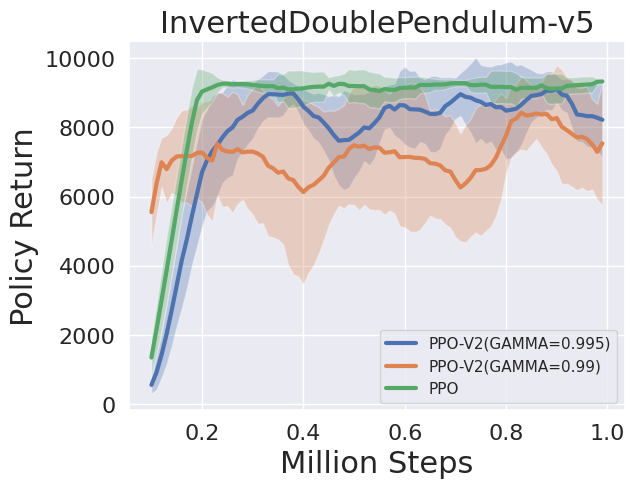

wobbly-firefly-174
magic-flower-173
gallant-sound-172
volcanic-frog-171
dandy-water-170
northern-universe-169
toasty-firefly-167
chocolate-voice-166
iconic-galaxy-161
avid-serenity-161
restful-lake-220
worldly-lake-217
worldly-lake-218
golden-water-219
curious-aardvark-216
warm-sunset-215
expert-breeze-214
dazzling-moon-213
vibrant-paper-212
dutiful-frost-211
lemon-valley-401
rosy-sun-40
prime-serenity-39
solar-vortex-38
stellar-moon-36
wobbly-elevator-34
eager-glade-35
ethereal-sea-36
crimson-bee-33
crimson-sky-30
polished-forest-31


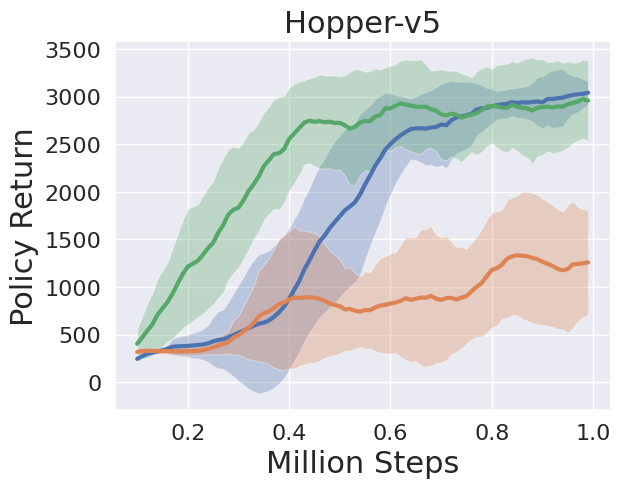

hopeful-sea-168
dashing-gorge-164
classic-surf-164
graceful-sea-160
winter-star-159
vague-resonance-157
glowing-morning-157
wise-deluge-152
sleek-shadow-152
likely-armadillo-151
lucky-aardvark-230
northern-sunset-228
ruby-galaxy-228
ethereal-night-227
rural-eon-226
copper-snowball-225
spring-serenity-224
splendid-silence-223
cool-shape-222
wobbly-terrain-221
classic-morning-9
glorious-totem-10
brisk-dew-8
charmed-dawn-7
fresh-bee-5
gentle-lion-6
crisp-galaxy-1
polar-pond-4
faithful-thunder-1
glowing-puddle-1


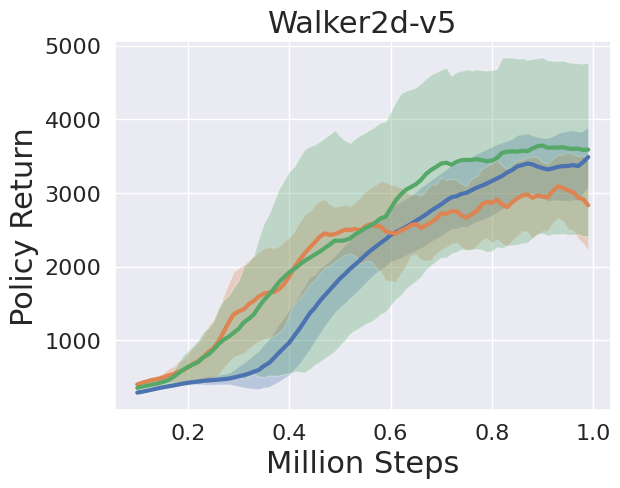

proud-durian-439
ancient-voice-180
exalted-wildflower-179
fresh-elevator-178
easy-armadillo-177
spring-pine-176
worthy-tree-175
twilight-puddle-163
curious-shadow-155
iconic-pyramid-156
grateful-night-154
different-forest-250
usual-durian-249
devout-fog-248
smooth-dust-247
rare-aardvark-246
smooth-dawn-245
fallen-river-244
olive-capybara-243
glad-disco-242
royal-grass-240
astral-cherry-411
glad-lake-408
playful-morning-408
glowing-leaf-406
ancient-sponge-402


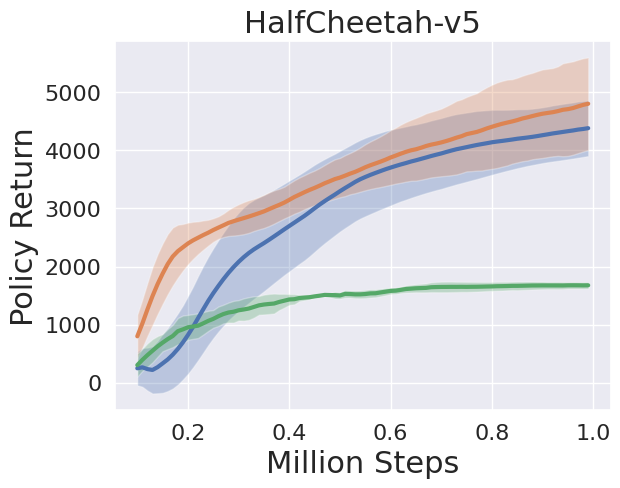

cerulean-morning-449
brisk-paper-448
dutiful-cherry-447
vibrant-pond-446
drawn-lion-445
dark-mountain-444
snowy-puddle-443
still-frost-442
kind-water-441
chocolate-sky-440
silver-grass-190
worldly-frost-189
graceful-elevator-187
deep-serenity-188
sparkling-yogurt-186
genial-gorge-185
polished-plasma-184
fanciful-snow-183
honest-feather-181
devout-dream-182
honest-wave-241
flowing-puddle-239
feasible-monkey-238
dainty-plant-237
bumbling-capybara-236
serene-wildflower-235
bright-cosmos-234
daily-oath-233
chocolate-meadow-231
volcanic-glade-232
eager-dawn-410
eternal-fire-407
easy-salad-403
major-voice-403
electric-salad-403


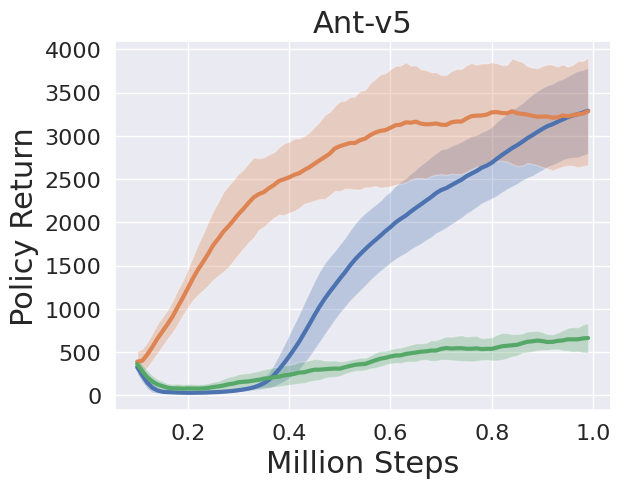

wise-waterfall-469
desert-dew-468
vague-breeze-467
woven-snow-466
fast-sea-464
toasty-butterfly-465
jolly-resonance-463
warm-darkness-462
faithful-durian-461
absurd-wildflower-460
dark-dawn-459
clear-music-458
toasty-silence-457
dutiful-water-456
wobbly-hill-455
sparkling-wind-454
leafy-moon-453
blooming-sea-452
morning-butterfly-451
misty-haze-450
decent-lake-260
daily-glade-259
hardy-oath-258
hearty-cloud-257
earthy-violet-256
grateful-puddle-252
noble-bird-251
hardy-pine-249
polished-butterfly-249
lucky-flower-248
good-sponge-260
grateful-cloud-259
devoted-darkness-258
winter-sky-257
expert-sunset-256
wild-wood-255
glamorous-voice-254
dainty-forest-252
leafy-gorge-253
super-dragon-251
celestial-sea-110
sage-night-109
eager-dream-106
curious-silence-108
rare-sky-107
earthy-blaze-102
peach-smoke-102
polar-night-105
deft-water-102
graceful-energy-101


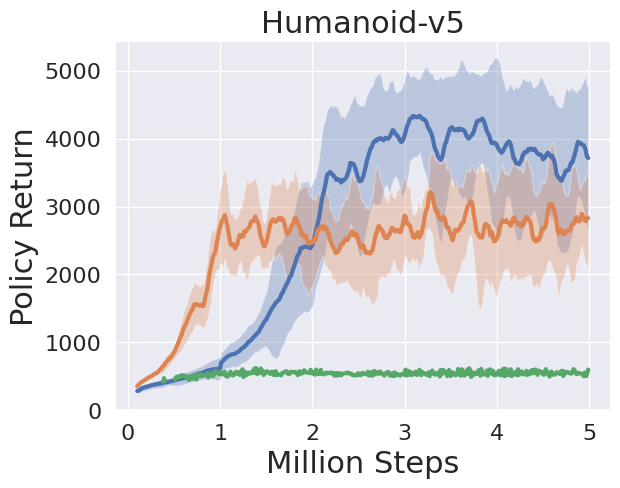

In [4]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_close", "iclr_995_tunisia_constant_temp"
runs_99 = api.runs(entity + "/" + project_99)
runs_995 = api.runs(entity + "/" + project_995)

runs = itertools.chain(runs_99,runs_995)
#runs = runs_995

def filter_ppo(run,env_name,gamma,normalize_reward):
    return run.config["env_name"] == env_name and gamma == run.config["gamma"] and run.config["algo_name"] == "ppo" and normalize_reward == run.config["normalize_reward"]


def filter_superppo(run,env_name,gamma,discount_actor,on_policy_data,momentum,temperature):
    
    if "temperature" not in run.config: run.config["temperature"]=0.05
    return run.config["env_name"] == env_name and run.config["algo_name"] == "superppo" and gamma == run.config["gamma"] and discount_actor == run.config["discount_actor"] and momentum == run.config["momentum"] and on_policy_data == run.config["on_policy_data"] and temperature==run.config["temperature"]


dc = {  "ppo-v2(gamma=0.995)":{"gamma":0.995,"on_policy_data":False,"discount_actor":True,"momentum":0.9,"temperature":0.05},
        "ppo-v2(gamma=0.99)":{"gamma":0.99,"on_policy_data":False,"discount_actor":True,"momentum":0.9,"temperature":0.05},
        "ppo":{"normalize_reward":True,"gamma":0.99}
}
      
      

legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
                
                
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if "v2" in algo:

                    if filter_superppo(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)
                        

                elif "ppo" in algo :        
                    
                    if filter_ppo(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)
                


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/benchmarks/"+env_name+"_benchmark.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

youthful-frost-297
azure-jazz-297
good-firefly-296
smart-haze-295
lucky-snow-290
lemon-glade-282
trim-donkey-280
unique-snowball-281
peach-plasma-273
prime-cosmos-273
crisp-field-320
soft-wildflower-319
wandering-snow-316
laced-pine-313
generous-oath-312
fancy-pyramid-310
zany-firebrand-307
exalted-hill-307
soft-wildflower-303
lunar-firefly-303
scarlet-jazz-318
morning-snow-315
driven-smoke-317
cerulean-sponge-314
dainty-cloud-311
curious-feather-309
misty-pyramid-305
avid-blaze-302
divine-fog-303
faithful-dew-301
charmed-fog-435
astral-river-429
peach-smoke-430
devoted-surf-419
stilted-plasma-412
clean-firebrand-401
fanciful-sunset-401
lunar-deluge-401
faithful-cloud-401
youthful-violet-401


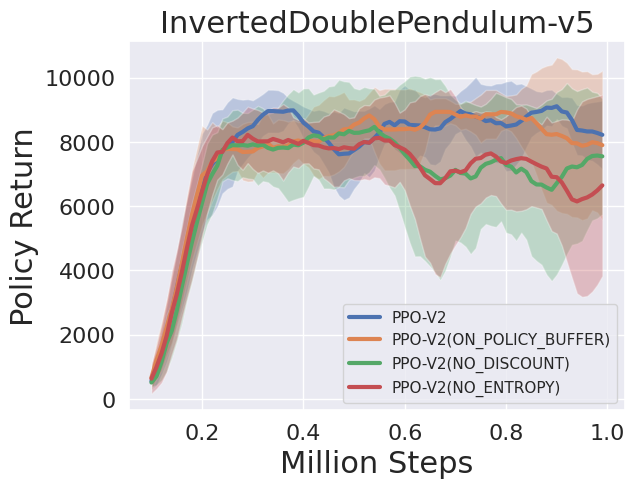

wobbly-firefly-174
magic-flower-173
gallant-sound-172
volcanic-frog-171
dandy-water-170
northern-universe-169
toasty-firefly-167
chocolate-voice-166
iconic-galaxy-161
avid-serenity-161
light-frost-342
lemon-violet-340
unique-tree-341
fiery-pyramid-339
lively-spaceship-338
atomic-serenity-333
genial-armadillo-335
polished-mountain-335
peachy-wave-333
solar-wood-332
sweet-darkness-343
ruby-sun-337
sandy-serenity-329
lunar-bee-328
distinctive-oath-327
lemon-wave-323
floral-sea-325
glowing-blaze-322
sandy-resonance-321
likely-snow-323
vital-music-436
different-resonance-428
fast-voice-413
avid-night-414
blooming-moon-414
deft-star-414
trim-dragon-414
exalted-universe-418
dulcet-grass-401
lunar-monkey-401


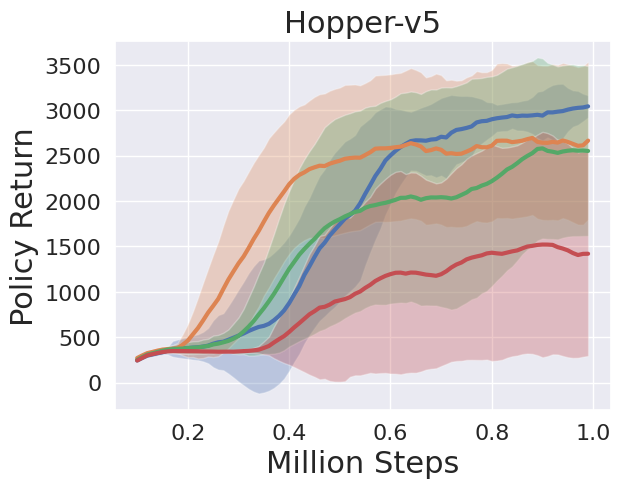

hopeful-sea-168
dashing-gorge-164
classic-surf-164
graceful-sea-160
winter-star-159
vague-resonance-157
glowing-morning-157
wise-deluge-152
sleek-shadow-152
likely-armadillo-151
fancy-snowflake-350
fancy-moon-349
stellar-aardvark-348
floral-planet-347
efficient-snow-346
cerulean-bird-345
whole-grass-344
comfy-wind-331
different-armadillo-330
crisp-tree-326
fresh-planet-363
efficient-glade-357
autumn-sponge-358
kind-durian-359
sparkling-waterfall-356
hearty-valley-355
toasty-bird-354
ruby-dragon-353
major-shadow-352
smooth-terrain-351
pious-planet-431
stellar-oath-425
effortless-flower-426
glamorous-sky-426
gentle-bush-423
rare-sky-422
pious-breeze-411
classic-forest-401
fallen-armadillo-401
sweet-armadillo-401


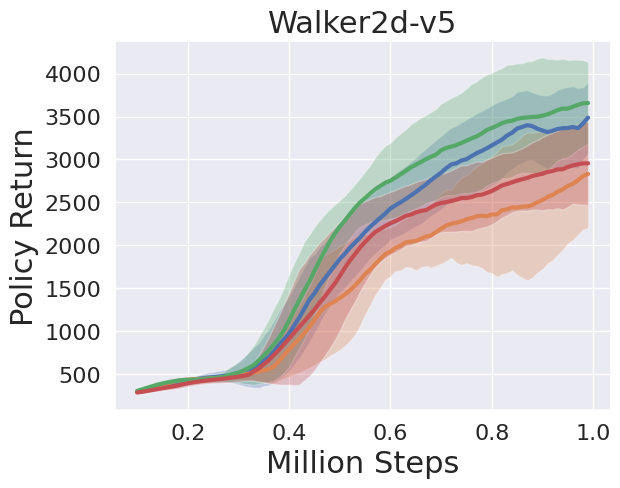

proud-durian-439
ancient-voice-180
exalted-wildflower-179
fresh-elevator-178
easy-armadillo-177
spring-pine-176
worthy-tree-175
twilight-puddle-163
curious-shadow-155
iconic-pyramid-156
grateful-night-154
resilient-lion-381
devout-bee-379
rose-waterfall-378
spring-sea-377
scarlet-wind-376
giddy-rain-375
treasured-pond-374
smooth-tree-371
sleek-meadow-373
wise-shadow-372
dandy-tree-370
worthy-river-369
wandering-cloud-367
gentle-waterfall-368
dark-snow-366
noble-bee-365
ethereal-dream-364
scarlet-fire-360
elated-surf-362
crisp-oath-361
peach-bird-438
pious-cloud-437
dark-snow-432
generous-wood-433
spring-yogurt-432
silver-disco-424
floral-deluge-421
peachy-water-420
trim-river-403


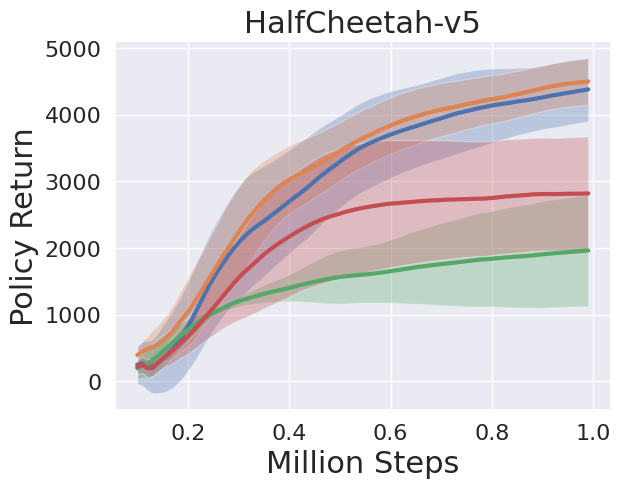

cerulean-morning-449
brisk-paper-448
dutiful-cherry-447
vibrant-pond-446
drawn-lion-445
dark-mountain-444
snowy-puddle-443
still-frost-442
kind-water-441
chocolate-sky-440
silver-grass-190
worldly-frost-189
graceful-elevator-187
deep-serenity-188
sparkling-yogurt-186
genial-gorge-185
polished-plasma-184
fanciful-snow-183
honest-feather-181
devout-dream-182
cool-lake-400
fallen-tree-389
volcanic-field-388
twilight-terrain-387
dry-cosmos-386
dark-darkness-384
graceful-breeze-385
fresh-waterfall-382
decent-dream-383
lively-puddle-380
smart-totem-399
ancient-firebrand-398
lunar-rain-397
grateful-leaf-396
major-frost-395
earnest-wave-394
playful-shadow-393
good-bush-392
firm-star-391
radiant-glitter-390
fallen-plant-500
chocolate-cloud-499
blooming-monkey-498
glowing-elevator-497
hearty-sun-496
ethereal-dragon-495
eager-puddle-494
happy-jazz-493
curious-dawn-492
neat-deluge-491


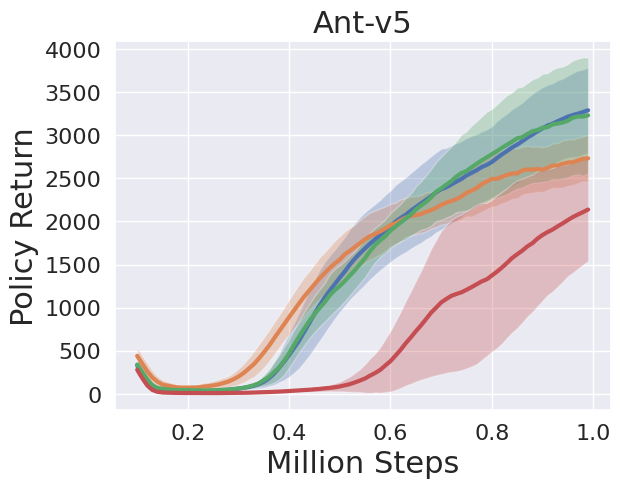

wise-waterfall-469
desert-dew-468
vague-breeze-467
woven-snow-466
fast-sea-464
toasty-butterfly-465
jolly-resonance-463
warm-darkness-462
faithful-durian-461
absurd-wildflower-460
dark-dawn-459
clear-music-458
toasty-silence-457
dutiful-water-456
wobbly-hill-455
sparkling-wind-454
leafy-moon-453
blooming-sea-452
morning-butterfly-451
misty-haze-450
decent-lake-260
daily-glade-259
hardy-oath-258
hearty-cloud-257
earthy-violet-256
grateful-puddle-252
noble-bird-251
hardy-pine-249
polished-butterfly-249
lucky-flower-248
deft-shape-481
peachy-armadillo-480
expert-sun-479
easy-dragon-478
charmed-microwave-477
swept-night-476
restful-night-475
royal-planet-473
pleasant-waterfall-473
fiery-firefly-472
firm-tree-471
revived-wood-470


KeyError: 'step'

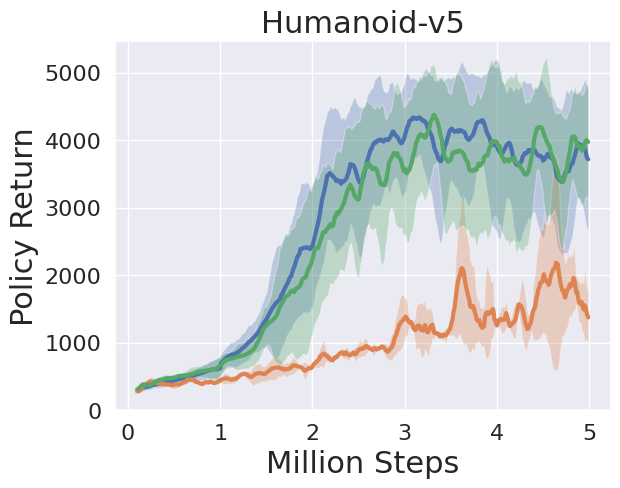

In [2]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_995_tunisia_notemp", "iclr_995_tunisia_constant_temp"
runs_99 = api.runs(entity + "/" + project_99)
runs_995 = api.runs(entity + "/" + project_995)

runs = itertools.chain(runs_99,runs_995)
#runs = runs_995


def filter_superppo(run,env_name,gamma,discount_actor,on_policy_data,momentum,temperature):
    
    if not "temperature" in run.config : run.config["temperature"]=0.05
    return run.config["env_name"] == env_name and run.config["algo_name"] == "superppo" and gamma == run.config["gamma"] and discount_actor == run.config["discount_actor"] and temperature == run.config["temperature"] and on_policy_data == run.config["on_policy_data"] and momentum == run.config["momentum"]


dc = {"ppo-v2":{"gamma":0.995,"on_policy_data":False,"discount_actor":True,"momentum":0.9,"temperature":0.05},
      "ppo-v2(on_policy_buffer)":{"gamma":0.995,"on_policy_data":True,"discount_actor":True,"momentum":0.9,"temperature":0.05},
      "ppo-v2(no_discount)":{"gamma":0.995,"on_policy_data":False,"discount_actor":False,"momentum":0.9,"temperature":0.05},
      "ppo-v2(no_entropy)":{"gamma":0.995,"on_policy_data":False,"discount_actor":True,"momentum":0.9,"temperature":0.}}
legends = [""]
env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    algo_name = dc.keys()
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
                
                
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if "v2" in algo:

                    if filter_superppo(run,env_name,**dc[algo]):
                        config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                        # .name is the human-readable name of the run.
                        name_list.append(run.name)
                        full_df = run.history(samples=10000)
                        tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                        tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                        tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                        tmp_df = tmp_df[["step","average return"]]
                        df = pd.concat([df, tmp_df], ignore_index=True)
                        print(run.name)
                        

          


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()

            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Policy Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/ablations/"+env_name+"_ablation.pdf", format="pdf", bbox_inches="tight")  
    plt.show()

In [ ]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "finishitto", "finishitto_995"

runs_995 = api.runs(entity + "/" + project_995)
#runs = itertools.chain(runs_99,runs_995,runs_onp)
runs = runs_995




env_name = "InvertedDoublePendulum-v5"

dc = {"TOP-PPO":{"gamma":0.995,"discount_actor":True,"momentum":0.,"on_policy_data":False},
      "-Discount PG":{"gamma":0.995,"discount_actor":False,"momentum":0.,"on_policy_data":False},
      "-Off policy":{"gamma":0.995,"discount_actor":True,"momentum":0.,"on_policy_data":True},
      "+Momentum":{"gamma":0.995,"discount_actor":True,"momentum":0.9,"on_policy_data":False},
      }
legends = [""]


env_names = ["InvertedDoublePendulum-v5","Hopper-v5","Walker2d-v5","HalfCheetah-v5","Ant-v5","Humanoid-v5"]
max_steps = [1e6,1e6,1e6,1e6,1e6,5e6]
legend = [True,False,False,False,False,False]

for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = ["TOP-PPO","-Discount PG","-Off policy","+Momentum"]
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if filter_superppo(run,env_name,**dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/episode.return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/episode.return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/ablations_995/"+env_name+"_ablation_995.pdf", format="pdf", bbox_inches="tight")  
    plt.show()


lemon-valley-401
rosy-sun-40
prime-serenity-39
solar-vortex-38
stellar-moon-36
wobbly-elevator-34
eager-glade-35
ethereal-sea-36
crimson-bee-33
crimson-sky-30
polished-forest-31
winter-morning-18
northern-resonance-11
rose-spaceship-8
misty-planet-6
light-tree-6
lemon-valley-401
rosy-sun-40
prime-serenity-39
solar-vortex-38
stellar-moon-36
wobbly-elevator-34
eager-glade-35
ethereal-sea-36
crimson-bee-33
crimson-sky-30
polished-forest-31
twilight-sun-98
iconic-sunset-100
divine-silence-99
olive-elevator-96
curious-fog-95
bumbling-oath-5
stilted-surf-4
tough-snowball-3
amber-terrain-1
genial-music-2
lyric-valley-85
likely-pond-84
tough-salad-82
twilight-snowball-82
light-armadillo-81


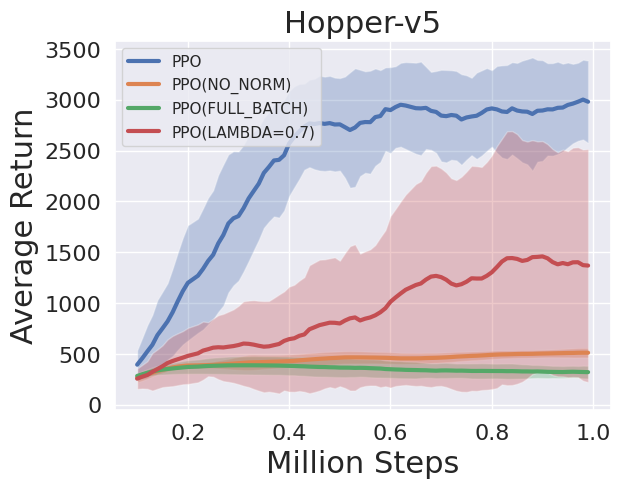

classic-morning-9
glorious-totem-10
brisk-dew-8
charmed-dawn-7
fresh-bee-5
gentle-lion-6
crisp-galaxy-1
polar-pond-4
faithful-thunder-1
glowing-puddle-1
stilted-music-40
giddy-cloud-38
olive-river-39
bumbling-universe-36
azure-hill-36
fancy-thunder-104
eager-snow-103
worldly-plasma-101
confused-resonance-102
hopeful-rain-97
honest-night-26
silver-disco-23
dashing-frost-21
worthy-cosmos-22
stoic-waterfall-23
sleek-moon-80
azure-dawn-76
fluent-yogurt-76
scarlet-disco-76
apricot-plasma-77


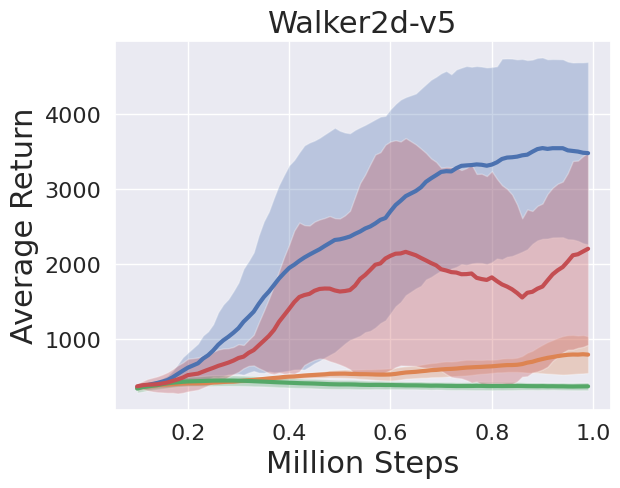

In [3]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools
import matplotlib

sns.set(font_scale=3.)
#matplotlib.rcParams.update({'font.size': 28})
sns.set_theme()

matplotlib.rcParams.update({'font.size': 50})



os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity, project_99,project_995 = "mahdikallel", "iclr_close", "iclr_ppo_diagnosis"

runs_995 = api.runs(entity + "/" + project_995)
runs_99 = api.runs(entity + "/" + project_99)
runs = itertools.chain(runs_99,runs_995,runs_99)





env_name = "InvertedDoublePendulum-v5"

dc = {"PPO":{"normalize_reward":True,"full_batch":False,"gae_lambda":0.95},
      "PPO(no_norm)":{"normalize_reward":False,"full_batch":False,"gae_lambda":0.95},
      "PPO(full_batch)":{"normalize_reward":True,"full_batch":True,"gae_lambda":0.95},
      "PPO(lambda=0.7)":{"normalize_reward":True,"full_batch":False,"gae_lambda":0.7},
      }
legends = [""]


env_names = ["Hopper-v5","Walker2d-v5"]
max_steps = [1e6,1e6]
legend = [True,False]


def filter_ppo(run,env_name,normalize_reward,gae_lambda,full_batch):
    
    
    if not "gae_lambda" in run.config : run.config["gae_lambda"]=0.95
    if not "full_batch" in run.config : run.config["full_batch"]=False
    return run.config["env_name"] == env_name and gae_lambda == run.config["gae_lambda"] and run.config["algo_name"] == "ppo" and normalize_reward == run.config["normalize_reward"] and full_batch == run.config["full_batch"]


for env_name,max_step,legend in zip(env_names,max_steps,legend):


    
    algo_name = dc.keys()
    
    for algo in algo_name:
            
            df = pd.DataFrame()
            config_list, name_list,run_list= [], [],[]
            for run in runs:
            
                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                
                if filter_ppo(run,env_name,**dc[algo]):
                    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
                    # .name is the human-readable name of the run.
                    name_list.append(run.name)
                    full_df = run.history(samples=10000)
                    tmp_df = full_df[['evaluation/undisc_policy_return','_step']].dropna(axis=0)
                    tmp_df["average return"] = tmp_df['evaluation/undisc_policy_return'].rolling(window=10).mean()
                    tmp_df['step'] = np.round(tmp_df['_step'] / 10000) * 10000
                    tmp_df = tmp_df[["step","average return"]]
                    df = pd.concat([df, tmp_df], ignore_index=True)
                    print(run.name)

            


            runs_df = pd.DataFrame({"config": config_list, "name": name_list})
            df = df[df["step"]<int(max_step)]
            x = df.groupby("step")["step"].mean()/1e6
            mean = df.groupby("step")["average return"].mean()
            #stderror = df.groupby("step")["average return"].std()/np.sqrt(df.groupby("step")["average return"].count())
            stderror = df.groupby("step")["average return"].std()
            
            #plt.axis('equal')
            plt.plot(x,mean,label=algo.upper(),linewidth=3)
            plt.fill_between(x,mean-stderror,mean+stderror, alpha=0.3)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            plt.xlabel('Million Steps',fontsize=22)
            plt.ylabel('Average Return',fontsize=22)
            plt.title(env_name,fontsize=22)
            #runs = itertools.chain(runs_99,runs_995)
            runs = itertools.chain(runs_99,runs_995)

    if legend : plt.legend()      
    plt.savefig("./plots/diagnostics/"+env_name+"diagnostic.pdf", format="pdf", bbox_inches="tight")  
    plt.show()